In [11]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-m9pi2q2z
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-m9pi2q2z
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!git clone https://github.com/modelscope/DiffSynth-Studio.git


fatal: destination path 'DiffSynth-Studio' already exists and is not an empty directory.


In [14]:
import sys, os

repo_path = "/content/DiffSynth-Studio"
sys.path.insert(0, repo_path)

print(repo_path in sys.path)


True


In [16]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [17]:
%%capture
%cd DiffSynth-Studio
!pip install -e .


In [18]:
import diffsynth
print(diffsynth.__file__)


/content/DiffSynth-Studio/diffsynth/__init__.py


In [19]:
# import diffsynth
import clip
from diffsynth.pipelines.qwen_image import (
    QwenImagePipeline, ModelConfig,
    QwenImageUnit_Image2LoRAEncode, QwenImageUnit_Image2LoRADecode
)
from modelscope import snapshot_download
from safetensors.torch import save_file
import torch
from PIL import Image

In [20]:
from diffsynth.pipelines.qwen_image import QwenImagePipeline, ModelConfig
import torch

vram_config = {
    "offload_dtype": "disk",
    "offload_device": "disk",
    "onload_dtype": torch.bfloat16,
    "onload_device": "cpu",
    "preparing_dtype": torch.bfloat16,
    "preparing_device": "cuda",
    "computation_dtype": torch.bfloat16,
    "computation_device": "cuda",
}
pipe = QwenImagePipeline.from_pretrained(
    torch_dtype=torch.bfloat16,
    device="cuda",
    model_configs=[
        ModelConfig(model_id="Qwen/Qwen-Image", origin_file_pattern="transformer/diffusion_pytorch_model*.safetensors", **vram_config),
        ModelConfig(model_id="Qwen/Qwen-Image", origin_file_pattern="text_encoder/model*.safetensors", **vram_config),
        ModelConfig(model_id="Qwen/Qwen-Image", origin_file_pattern="vae/diffusion_pytorch_model.safetensors", **vram_config),
    ],
    tokenizer_config=ModelConfig(model_id="Qwen/Qwen-Image", origin_file_pattern="tokenizer/"),
    vram_limit=torch.cuda.mem_get_info("cuda")[1] / (1024 ** 3) - 0.5,
)

2026-01-04 13:24:42,858 - modelscope - INFO - Got 9 files, start to download ...


Processing 9 items:   0%|          | 0.00/9.00 [00:00<?, ?it/s]

2026-01-04 14:17:50,930 - modelscope - INFO - Download model 'Qwen/Qwen-Image' successfully.


Loading models from: [
    "./models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00003-of-00009.safetensors",
    "./models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00009-of-00009.safetensors",
    "./models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00006-of-00009.safetensors",
    "./models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00004-of-00009.safetensors",
    "./models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00007-of-00009.safetensors",
    "./models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00008-of-00009.safetensors",
    "./models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00001-of-00009.safetensors",
    "./models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00002-of-00009.safetensors",
    "./models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00005-of-00009.safetensors"
]
Loaded model: {
    "model_name": "qwen_image_dit",
    "model_class": "diffsynth.models.qwen_image_dit.QwenImageDiT",
  

2026-01-04 14:17:56,635 - modelscope - INFO - Got 4 files, start to download ...


...

Loading models from: "./models/Qwen/Qwen-Image/vae/diffusion_pytorch_model.safetensors"
Loaded model: {
    "model_name": "qwen_image_vae",
    "model_class": "diffsynth.models.qwen_image_vae.QwenImageVAE",
    "extra_kwargs": null
}
Using qwen_image_text_encoder from [
    "./models/Qwen/Qwen-Image/text_encoder/model-00002-of-00004.safetensors",
    "./models/Qwen/Qwen-Image/text_encoder/model-00001-of-00004.safetensors",
    "./models/Qwen/Qwen-Image/text_encoder/model-00004-of-00004.safetensors",
    "./models/Qwen/Qwen-Image/text_encoder/model-00003-of-00004.safetensors"
].
Using qwen_image_dit from [
    "./models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00003-of-00009.safetensors",
    "./models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00009-of-00009.safetensors",
    "./models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00006-of-00009.safetensors",
    "./models/Qwen/Qwen-Image/transformer/diffusion_pytorch_model-00004-of-00009.safetensors",
    "./

2026-01-04 14:41:07,405 - modelscope - INFO - Got 6 files, start to download ...


Processing 6 items:   0%|          | 0.00/6.00 [00:00<?, ?it/s]

2026-01-04 14:41:08,721 - modelscope - INFO - Download model 'Qwen/Qwen-Image' successfully.


No siglip2_image_encoder models available. This is not an error.
No dinov3_image_encoder models available. This is not an error.
No qwen_image_image2lora_style models available. This is not an error.
No qwen_image_image2lora_coarse models available. This is not an error.
No qwen_image_image2lora_fine models available. This is not an error.


In [21]:
pipe.load_lora(pipe.dit, "/content/drive/Shareddrives/NLP - Text2Img/Khuong/model_style.safetensors")

720 tensors are patched by LoRA. You can use `pipe.clear_lora()` to clear all LoRA layers.


In [22]:
prompts = ["Dinh Bo Linh standing at the front of his army, holding a sword, soldiers behind him with ancient Vietnamese banners, hills and rivers in the background, armored warriors preparing for battle, no text, no letters, no symbols",
           "The Trưng Sisters riding war elephants side by side, wearing ancient Vietnamese armor, soldiers following them, battlefield filled with flags and drums, mountains in the distance, no text, no letters, no symbols",
           "Ly Thai To standing on a platform near the Red River, officials and guards surrounding him, a dragon appearing above the river, ancient palaces and city structures behind, no text, no letters, no symbols",
           "Tran Hung Dao commanding from a riverbank, wooden stakes emerging from the river, enemy ships trapped among the stakes, Vietnamese soldiers attacking from boats, clouds and smoke over the battlefield, no text, no letters, no symbols",
           "Emperor Quang Trung riding at the head of his army, soldiers advancing through smoke and fire, broken enemy formations, banners waving, hills and villages in the background, no text, no letters, no symbols",
           "Le Loi holding a sword raised toward the sky, soldiers gathered around him, forested mountains behind, tents and weapons on the ground, morning mist covering the battlefield, no text, no letters, no symbols",
           "Ho Chi Minh standing on a stage at Ba Dinh Square, a large crowd in front of him, flags held by the people, surrounding buildings visible, clear sky above, no text, no letters, no symbols",
           "Vietnamese soldiers moving through t renches and hills, carrying weapons and supplies, artillery positioned on the mountains, smoke rising from the battlefield, dense forest around, no text, no letters, no symbols",
           "People gathered around a large bronze drum, dancers and musicians surrounding it, traditional clothing, boats and animals depicted on the drum surface, river and trees nearby, no text, no letters, no symbols",
           "The Vietnamese emperor seated on a throne inside a palace, mandarins standing in rows on both sides, guards near the columns, traditional palace architecture visible, no text, no letters, no symbols"
          ]

In [23]:
prompt = prompts[9] #TODO: change this from 0 to 9

In [24]:
%%time
image = pipe(prompt, height=576, width=1024, num_inference_steps=25)
image.save("image.jpg")

100%|██████████| 25/25 [2:33:58<00:00, 369.54s/it]


CPU times: user 20min 27s, sys: 7min 39s, total: 28min 7s
Wall time: 2h 35min 13s


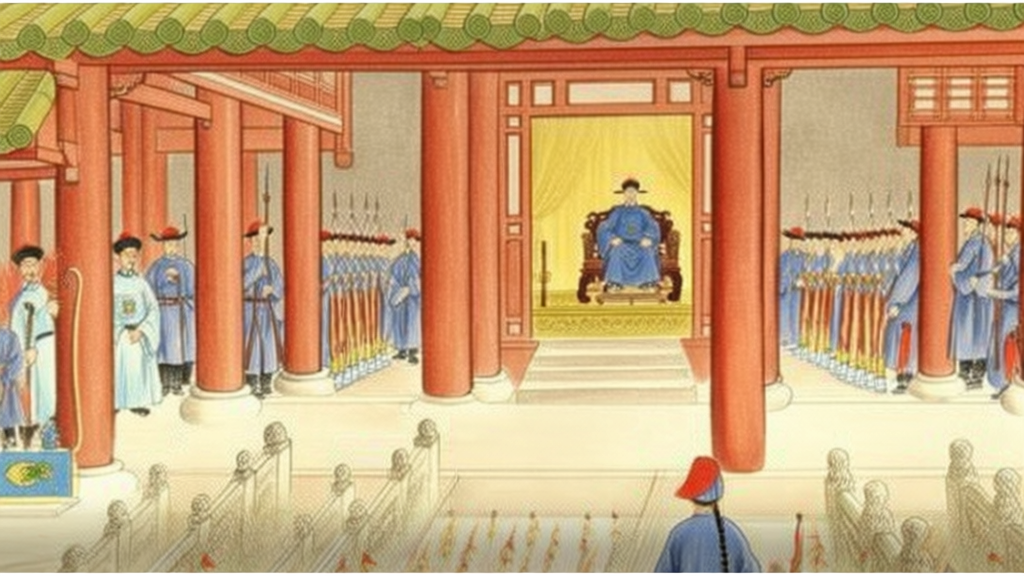

In [25]:
image

In [26]:
image.save("/content/drive/Shareddrives/NLP - Text2Img/Khuong/image_An.jpg")

In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [28]:
clip_model, preprocess = clip.load("ViT-B/32", device=device)

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 127MiB/s]


In [29]:
text_token = clip.tokenize([prompt]).to(device)

with torch.no_grad():
    text_features = clip_model.encode_text(text_token)


image_tensor = preprocess(image).unsqueeze(0).to(device)
with torch.no_grad():
    image_features = clip_model.encode_image(image_tensor)
similarity = (image_features @ text_features.T).item()
print(similarity)


24.296875
